#Project Overview

This notebook implements a deep learning–based image compression pipeline using a U-Net model to learn importance maps for adaptive quantization. It combines classical JPEG-inspired techniques (DCT, quantization) with neural networks to improve rate–distortion performance. The workflow covers data preprocessing, model training, evaluation, and visualization of compression behavior.


## Installing and Importing Required Libraries

In [1]:
# Install required libraries (run once in a fresh environment)
!pip install torch torchvision
!pip install numpy opencv-python matplotlib tqdm
!pip install pytorch-msssim

import numpy as np
import cv2 as cv
import random
import matplotlib.pyplot as plt
from PIL import Image
import io
import os

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from torch.utils.data import DataLoader
from pytorch_msssim import ssim as ssim_fn

In [2]:
# Drive mounting
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Patch Extraction (utility)

Extracts overlapping patches from an image using a sliding window. The stride controls how much overlap exists between patches.


In [3]:
# Data loading / preprocessing helper

def extract_patches(img, patch_size=96, stride=48):
    patches = []
    h, w, _ = img.shape  # image height and width

    # Slide a window across the image to extract overlapping patches
    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size]
            patches.append(patch)

    return patches

#Data loading

The dataset is first loaded from raw image files, where each high-resolution image is paired with its corresponding low-resolution version. To standardize training, all images are resized and converted to RGB format.

 Since this step is slow, the processed arrays are saved as `.npy` files for faster reuse. For subsequent runs, the dataset can be loaded directly from these saved files, significantly reducing setup time.


In [6]:
# Paths to original dataset (used during initial preprocessing)

hr_path = "/content/drive/MyDrive/imagecompression/train/high_res"
lr_path = "/content/drive/MyDrive/imagecompression/train/low_res"
files = sorted(os.listdir(hr_path))

In [19]:
# Loads raw images, resizes them, and prepares paired HR/LR data.
# Run once, then save as .npy for faster reuse.

# hr_path = "/content/drive/MyDrive/imagecompression/train/high_res"
# lr_path = "/content/drive/MyDrive/imagecompression/train/low_res"

# hr_images = []
# lr_images = []

# files = sorted(os.listdir(hr_path))

# for file in files:
#     hr = cv.imread(os.path.join(hr_path, file))
#     lr = cv.imread(os.path.join(lr_path, file))

#     if hr is None or lr is None:
#         continue

#     hr = cv.cvtColor(hr, cv.COLOR_BGR2RGB)
#     lr = cv.cvtColor(lr, cv.COLOR_BGR2RGB)

#     hr = cv.resize(hr, (256, 256))
#     lr = cv.resize(lr, (256, 256))

#     hr_images.append(hr)
#     lr_images.append(lr)

# print("Loaded pairs:", len(hr_images))
# print("Sample shape:", hr_images[0].shape)

In [21]:
# Save processed arrays to disk for faster loading later

# import numpy as np

# np.save("/content/drive/MyDrive/imagecompression/hr_images.npy", np.array(hr_images))
# np.save("/content/drive/MyDrive/imagecompression/lr_images.npy", np.array(lr_images))

# print("Saved preprocessed datasets")

In [24]:
# Data loading (fast path)

import numpy as np

hr_images = np.load("/content/drive/MyDrive/imagecompression/hr_images.npy")
lr_images = np.load("/content/drive/MyDrive/imagecompression/lr_images.npy")

print("Loaded preprocessed data")
print("Dataset shape:", hr_images.shape)

Loaded preprocessed data
Dataset shape: (685, 256, 256, 3)


#Importance Normalization

Normalizes the importance map to maintain a stable scale across different inputs. It also limits extreme values and applies slight smoothing to produce more consistent and usable importance maps.


In [25]:
def normalize_importance(importance):
    # normalize by mean to keep scale consistent across images
    importance = importance / (importance.mean(dim=[1, 2, 3], keepdim=True) + 1e-6)

    # clamp values to avoid extreme importance weights
    importance = torch.clamp(importance, 0.1, 2.0)

    # smooth the map slightly to reduce noise and artifacts
    importance = F.avg_pool2d(importance, kernel_size=3, stride=1, padding=1)

    return importance

#Importance Map Inference Evaluation

Generates an importance map from the model using HR and LR inputs. The output highlights regions that should be preserved with higher quality during compression.


In [26]:
def get_importance_map(hr, lr):
    model.eval()  # switch model to inference mode

    # normalize pixel values to [0, 1]
    hr_norm = hr / 255.0
    lr_norm = lr / 255.0

    # handle grayscale images by expanding to 3 channels
    if hr_norm.ndim == 2:
        hr_norm = np.stack([hr_norm] * 3, axis=2)
    if lr_norm.ndim == 2:
        lr_norm = np.stack([lr_norm] * 3, axis=2)

    # basic sanity check for input shape
    if hr.ndim != 3 or hr.shape[2] != 3:
        raise ValueError(f"Invalid HR shape: {hr.shape}")

    # combine HR and LR into a single 6-channel input
    inp = np.concatenate([hr_norm, lr_norm], axis=2)

    # convert to tensor (C, H, W) and move to device
    inp_tensor = torch.from_numpy(inp).permute(2, 0, 1).unsqueeze(0).float().to(device)

    # run model without gradient tracking
    with torch.no_grad():
        importance = model(inp_tensor)
        importance = normalize_importance(importance)  # rescale output

    return importance.squeeze().cpu().numpy()

# Custom Dataset

Defines a custom dataset that returns paired HR and LR image patches. Random flips are applied for simple data augmentation to improve generalization during training.


In [27]:
class ImportanceDataset(torch.utils.data.Dataset):
    def __init__(self, hr_patches, lr_patches):
        self.hr = hr_patches  # list/array of high-resolution patches
        self.lr = lr_patches  # corresponding low-resolution patches

    def __len__(self):
        return len(self.hr)  # total number of samples

    def __getitem__(self, idx):
        # fetch paired HR/LR patch
        hr = self.hr[idx]
        lr = self.lr[idx]

        # apply simple data augmentation (random flips)
        if random.random() > 0.5:
            hr = hr[:, ::-1, :].copy()  # horizontal flip
            lr = lr[:, ::-1, :].copy()

        if random.random() > 0.5:
            hr = hr[::-1, :, :].copy()  # vertical flip
            lr = lr[::-1, :, :].copy()

        # convert numpy arrays to torch tensors (C, H, W format)
        hr = torch.from_numpy(hr).permute(2, 0, 1).float()
        lr = torch.from_numpy(lr).permute(2, 0, 1).float()

        return hr, lr

# Patch Dataset Creation

Builds the training dataset by extracting aligned patches from HR and LR images and normalizing them. This increases the number of training samples and standardizes the input range.


In [28]:
hr_patches = []
lr_patches = []

# extract patches from each HR/LR image pair
for hr, lr in zip(hr_images, lr_images):
    hr_ps = extract_patches(hr, patch_size=96, stride=48)
    lr_ps = extract_patches(lr, patch_size=96, stride=48)

    # store corresponding patches after normalization
    for hr_patch, lr_patch in zip(hr_ps, lr_ps):
        hr_patches.append(hr_patch.astype(np.float32) / 255.0)
        lr_patches.append(lr_patch.astype(np.float32) / 255.0)

print("Total patches:", len(hr_patches))

Total patches: 10960


#Dataset Subsampling

In [29]:
max_patches = 30000  # limit dataset size for faster training and memory usage

# truncate to a fixed number of patches
hr_patches = hr_patches[:max_patches]
lr_patches = lr_patches[:max_patches]

print("Using patches:", len(hr_patches))

Using patches: 10960


In [30]:
max_patches = 30000  # cap dataset size

# keep only a subset of patches
hr_patches = hr_patches[:max_patches]
lr_patches = lr_patches[:max_patches]

In [31]:
#Shuffles the dataset to randomize training samples while preserving alignment between HR and LR pairs, which helps improve training stability.

# shuffle dataset while keeping HR/LR pairs aligned
combined = list(zip(hr_patches, lr_patches))
random.shuffle(combined)

# unzip back into separate lists
hr_patches, lr_patches = zip(*combined)

# convert from tuples back to lists
hr_patches = list(hr_patches)
lr_patches = list(lr_patches)

In [32]:
# Basic sanity checks for Data Validation

print("Patches:", len(hr_patches))
print("Example patch shape:", hr_patches[0].shape)

# ensure patch dimensions are as expected
assert hr_patches[0].shape == (96, 96, 3), "Patch shape is broken"

Patches: 10960
Example patch shape: (96, 96, 3)


In [33]:
# Verify number of files in each directory

print("HR files:", len(os.listdir(hr_path)))
print("LR files:", len(os.listdir(lr_path)))

HR files: 685
LR files: 685


In [34]:
print(len(hr_images))
print(len(hr_patches))

685
10960


In [35]:
# Verifies that all image pairs can be successfully loaded, helping identify missing or corrupted files before preprocessing.

# valid = 0
# missing = 0

# for file in files:
#     hr = cv.imread(os.path.join(hr_path, file))
#     lr = cv.imread(os.path.join(lr_path, file))

#     if hr is not None and lr is not None:
#         valid += 1
#     else:
#         missing += 1

# print("Valid pairs:", valid)
# print("Missing pairs:", missing)

# Train / Validation Split

Splits the dataset into training and validation sets and prepares batched loaders for efficient iteration during training.


In [36]:
from torch.utils.data import DataLoader

# create dataset from patches
dataset = ImportanceDataset(hr_patches, lr_patches)

# split into training and validation sets
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

# create data loaders for batching
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

# Defining U-Net Architecture

Implements a U-Net architecture that takes a 6-channel input (concatenated HR and LR images) and predicts a single-channel importance map. The encoder progressively downsamples the input to capture higher-level features, while the decoder upsamples and reconstructs spatial detail.

Skip connections between encoder and decoder layers help preserve fine-grained information, which is important for accurately identifying visually significant regions. The final output is passed through a sigmoid activation to produce a normalized importance map in the range [0, 1].


In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        # Encoder: progressively downsample and extract features
        self.enc1 = self.conv_block(6, 32)
        self.enc2 = self.conv_block(32, 64)
        self.enc3 = self.conv_block(64, 128)

        # Bottleneck: deepest representation
        self.bottleneck = self.conv_block(128, 256)

        # Decoder: upsample and combine with encoder features (skip connections)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = self.conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = self.conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = self.conv_block(64, 32)

        # Output: single-channel importance map
        self.final = nn.Conv2d(32, 1, 1)

    def conv_block(self, in_c, out_c):
        # basic conv block: Conv → BN → ReLU (x2)
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder path
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e3, 2))

        # Decoder path with skip connections
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # final output in [0, 1]
        return torch.sigmoid(self.final(d1))

# Training Setup

Initializes the model, optimizer, and loss function, and configures the device for training.


In [38]:
# device setup (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# initialize model
model = UNet().to(device)

# optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

In [39]:
# learning rate scheduler (reduces LR when validation loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=4, factor=0.5
)

# Edge Loss

Computes a loss based on edge differences using a Sobel filter, encouraging the model to preserve important structural details in the predicted importance map.


In [40]:
import torch.nn.functional as F

def edge_loss(pred, target):
    # Sobel filter to capture horizontal edges
    sobel_x = torch.tensor([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=torch.float32).to(pred.device)
    sobel_x = sobel_x.view(1, 1, 3, 3)

    # compute edge maps for prediction and target
    pred_edge = F.conv2d(pred, sobel_x, padding=1)
    target_edge = F.conv2d(target, sobel_x, padding=1)

    # L1 loss between edge responses
    return F.l1_loss(pred_edge, target_edge)

# Quantization Matrix

Generates a JPEG-style quantization matrix based on a given quality factor. Lower quality increases compression by using larger quantization values, while higher quality preserves more detail.


In [41]:
def get_quantization_matrix(quality):

    # standard JPEG quantization matrix (quality = 50 baseline)
    Q50 = np.array([
        [16, 11, 10, 16, 24, 40, 51, 61],
        [12, 12, 14, 19, 26, 58, 60, 55],
        [14, 13, 16, 24, 40, 57, 69, 56],
        [14, 17, 22, 29, 51, 87, 80, 62],
        [18, 22, 37, 56, 68, 109, 103, 77],
        [24, 35, 55, 64, 81, 104, 113, 92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103, 99]
    ], dtype=np.float32)

    # scale factor based on JPEG quality setting
    if quality < 50:
        scale = 5000 / quality
    else:
        scale = 200 - 2 * quality

    # scale and normalize the quantization matrix
    Q = (Q50 * scale + 50) / 100

    return np.clip(Q, 1, None)  # ensure values are >= 1

# Frequency Transform (DCT / IDCT)

Implements forward and inverse DCT using FFT operations in PyTorch, allowing the transform to run efficiently on GPU without relying on external libraries.


In [42]:
def dct2d_torch(block):
    # DCT-II approximation using FFT (fully in PyTorch, GPU-friendly)
    B, C, H, W = block.shape

    # rearrange input for FFT-based DCT
    v = torch.cat([block[:, :, ::2, :], block[:, :, 1::2, :].flip(2)], dim=2)
    v = torch.cat([v[:, :, :, ::2], v[:, :, :, 1::2].flip(3)], dim=3)

    V = torch.fft.fft2(v)

    # create frequency phase shifts
    k_h = torch.arange(H, device=block.device, dtype=torch.float32)
    k_w = torch.arange(W, device=block.device, dtype=torch.float32)

    ph = torch.exp(-1j * torch.pi * k_h / (2 * H)).reshape(1, 1, H, 1)
    pw = torch.exp(-1j * torch.pi * k_w / (2 * W)).reshape(1, 1, 1, W)

    # take real component as DCT output
    dct = (V * ph * pw).real
    return dct


def idct2d_torch(dct_block):
    # inverse DCT using FFT (reconstruct spatial domain)
    B, C, H, W = dct_block.shape

    k_h = torch.arange(H, device=dct_block.device, dtype=torch.float32)
    k_w = torch.arange(W, device=dct_block.device, dtype=torch.float32)

    ph = torch.exp(1j * torch.pi * k_h / (2 * H)).reshape(1, 1, H, 1)
    pw = torch.exp(1j * torch.pi * k_w / (2 * W)).reshape(1, 1, 1, W)

    x = torch.complex(dct_block, torch.zeros_like(dct_block)) * ph * pw

    # mirror to reconstruct full spectrum for inverse FFT
    top = x
    bottom = torch.zeros_like(x)
    bottom[:, :, 1:, :] = x[:, :, 1:, :].flip(2)
    full_h = torch.cat([top, bottom], dim=2)

    left = full_h
    right = torch.zeros_like(full_h)
    right[:, :, :, 1:] = full_h[:, :, :, 1:].flip(3)
    full = torch.cat([left, right], dim=3)

    out = torch.fft.ifft2(full).real
    return out[:, :, :H, :W]

# Adaptive Compression

Applies block-wise compression using DCT and a learned importance map to adjust quantization strength. More important regions are preserved with higher quality, while less important areas are compressed more aggressively.


In [43]:
def process_image_torch(image, importance_map, quality, alpha=1.0):
    B, C, H, W = image.shape
    block_size = 8

    # base JPEG quantization matrix
    Q_base = torch.tensor(
        get_quantization_matrix(quality),
        device=image.device,
        dtype=image.dtype
    )

    reconstructed = torch.zeros_like(image)

    # compute importance score per 8x8 block
    scores = []
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            if i+8 <= H and j+8 <= W:
                imp_block = importance_map[:, :, i:i+8, j:j+8]
                scores.append(imp_block.mean())

    scores_tensor = torch.stack(scores)

    # derive adaptive scaling factors from importance
    raw_scales = 1.0 + alpha * (1.0 - scores_tensor) ** 2

    # normalize scales to keep overall bitrate stable
    raw_scales = raw_scales / (raw_scales.mean() + 1e-6)
    raw_scales = raw_scales * 1.05  # slight global compression bias
    raw_scales = torch.clamp(raw_scales, 0.3, 4.0)

    block_idx = 0
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            block = image[:, :, i:i+8, j:j+8]
            if block.shape[-1] != 8 or block.shape[-2] != 8:
                continue

            scale = raw_scales[block_idx]
            block_idx += 1

            Q = Q_base * scale

            # DCT → quantization → dequantization → IDCT
            dct_block = dct2d_torch(block)
            quant = dct_block / Q
            quant_rounded = (quant.round() - quant).detach() + quant
            dequant = quant_rounded * Q
            recon = idct2d_torch(dequant)

            reconstructed[:, :, i:i+8, j:j+8] = recon

    return torch.clamp(reconstructed, 0, 1)

# Edge Map Computation

Computes a pixel-level edge map using Sobel filters, capturing image gradients that highlight structural details. The result is normalized to maintain consistent scale across inputs.


In [44]:
def compute_edge_map(img):
    # convert to grayscale for edge detection
    gray = img.mean(dim=1, keepdim=True)

    # Sobel filters (horizontal and vertical gradients)
    sobel_x = torch.tensor([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]],
                           dtype=torch.float32, device=img.device).view(1, 1, 3, 3)

    sobel_y = torch.tensor([[1, 2, 1],
                            [0, 0, 0],
                            [-1, -2, -1]],
                           dtype=torch.float32, device=img.device).view(1, 1, 3, 3)

    # compute gradient magnitude
    gx = F.conv2d(gray, sobel_x, padding=1)
    gy = F.conv2d(gray, sobel_y, padding=1)
    edge = torch.sqrt(gx**2 + gy**2)

    # normalize for stable scaling
    edge = edge / (edge.mean(dim=[1, 2, 3], keepdim=True) + 1e-6)

    return edge

In [45]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


# Training Loop

Trains the model to generate importance maps that guide adaptive compression. The objective combines reconstruction quality with structural consistency (edge alignment), while encouraging sparse and meaningful importance distributions.

A key component is the comparison against standard JPEG compression: the model is explicitly rewarded when its importance-guided reconstruction outperforms a baseline using uniform quantization. Validation tracks both distortion (RMSE) and a bitrate proxy, allowing the model to balance compression efficiency and visual quality.


In [46]:
# ================= TRAINING LOOP =================
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("Training Importance UNet...")

scaler = torch.amp.GradScaler("cuda")

# optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=4, factor=0.5
)

best_loss = float('inf')

train_losses = []
val_losses = []
epoch_bpp = []
epoch_rmse = []

for epoch in range(20):

    model.train()
    train_loss = 0

    for hr, lr in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):

        hr = hr.to(device)
        lr = lr.to(device)

        # combine HR + LR → 6-channel input
        imgs = torch.cat([hr, lr], dim=1)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            # -------- forward pass --------
            importance = model(imgs)
            importance = normalize_importance(importance)

            # reconstruct using adaptive compression
            reconstructed = process_image_torch(hr, importance, quality=40, alpha=1.0)

            # -------- loss components --------
            edge_target = compute_edge_map(hr)
            edge_loss = F.mse_loss(importance, edge_target)  # structural alignment

            distortion = F.mse_loss(reconstructed, hr)  # reconstruction quality

            sparsity = importance.mean()  # encourages fewer high-importance regions
            mid_penalty = -torch.mean((importance - 0.5) ** 2)  # avoids mid-range values

            # baseline JPEG comparison (no importance guidance)
            with torch.no_grad():
                ones_map = torch.ones_like(importance)
                std_recon = process_image_torch(hr, ones_map, quality=40, alpha=0.0)
                std_distortion = F.mse_loss(std_recon, hr)

            improvement = std_distortion - distortion  # reward outperforming baseline

            # final combined loss
            loss = (
                distortion
                + 0.1 * edge_loss
                + 0.05 * sparsity
                + 0.02 * mid_penalty
                - 0.3 * improvement
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    total_rmse = 0
    total_bpp = 0
    count = 0

    with torch.no_grad():
        for hr, lr in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):

            hr = hr.to(device)
            lr = lr.to(device)

            imgs = torch.cat([hr, lr], dim=1)

            with torch.amp.autocast("cuda"):

                importance = model(imgs)
                importance = normalize_importance(importance)

                reconstructed = process_image_torch(hr, importance, quality=40, alpha=1.0)
                reconstructed = torch.clamp(reconstructed, 0, 1)

                # -------- loss components --------
                edge_target = compute_edge_map(hr)
                edge_loss = F.mse_loss(importance, edge_target)

                distortion = F.mse_loss(reconstructed, hr)

                # baseline comparison
                ones_map = torch.ones_like(importance)
                std_recon = process_image_torch(hr, ones_map, quality=40, alpha=0.0)
                std_distortion = F.mse_loss(std_recon, hr)

                improvement = std_distortion - distortion

                sparsity = importance.mean()
                mid_penalty = -torch.mean((importance - 0.5) ** 2)

                loss = (
                    distortion
                    + 0.1 * edge_loss
                    + 0.05 * sparsity
                    + 0.02 * mid_penalty
                    - 0.3 * improvement
                )

            val_loss += loss.item()

            # metrics
            rmse = torch.sqrt(F.mse_loss(reconstructed, hr)).item()
            bpp = importance.mean().item()  # proxy for bitrate

            total_rmse += rmse
            total_bpp += bpp
            count += 1

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    avg_rmse = total_rmse / count
    avg_bpp = total_bpp / count

    epoch_rmse.append(avg_rmse)
    epoch_bpp.append(avg_bpp)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"           RMSE: {avg_rmse:.4f} | BPP (proxy): {avg_bpp:.4f}")

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"           LR: {current_lr:.2e}")

    # save best model
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved best model")

Training Importance UNet...


Epoch 1 [Val]: 100%|██████████| 35/35 [00:10<00:00,  3.26it/s]


Epoch 1 | Train Loss: 0.4376 | Val Loss: 0.4292
           RMSE: 0.3956 | BPP (proxy): 0.9206
           LR: 1.00e-04
Saved best model


Epoch 2 [Val]: 100%|██████████| 35/35 [00:10<00:00,  3.25it/s]


Epoch 2 | Train Loss: 0.4208 | Val Loss: 0.4223
           RMSE: 0.3956 | BPP (proxy): 0.8873
           LR: 1.00e-04
Saved best model


...

Epoch 18 | Train Loss: 0.4016 | Val Loss: 0.4068
           RMSE: 0.3961 | BPP (proxy): 0.6337
           LR: 1.00e-04


Epoch 19 [Val]: 100%|██████████| 35/35 [00:10<00:00,  3.23it/s]


Epoch 19 | Train Loss: 0.4013 | Val Loss: 0.4067
           RMSE: 0.3961 | BPP (proxy): 0.6380
           LR: 5.00e-05


Epoch 20 [Val]: 100%|██████████| 35/35 [00:09<00:00,  3.54it/s]

Epoch 20 | Train Loss: 0.4013 | Val Loss: 0.4065
           RMSE: 0.3961 | BPP (proxy): 0.6514
           LR: 5.00e-05
Saved best model


In [47]:
#Rescales the importance map to maintain a stable average value and limits extreme values to ensure consistent behavior during compression.

# normalize importance to have consistent mean scale
importance = importance / (importance.mean(dim=[1, 2, 3], keepdim=True) + 1e-6)

# clamp to avoid extreme values
importance = torch.clamp(importance, 0.1, 2)

##Error Evaluation

The Mean Squared Error (MSE) between the predicted importance maps and the ground truth maps is computed to evaluate model performance.

A bar chart is plotted to visualize the prediction error for each test image and the average error across the subset.

In [48]:
#Adds the project directory to the Python path to enable importing custom utility functions.

import sys
sys.path.append('/content/drive/MyDrive/imagecompression')
import compression_utils as cu

In [49]:
#Allows reloading the custom module after modifications without restarting the runtime.

# reload module after making changes (optional)
# import importlib
# importlib.reload(cu)

# SSIM Evaluation

Computes the Structural Similarity Index (SSIM) between the original and compressed images, providing a perceptual measure of image quality beyond pixel-wise error.


In [50]:
from pytorch_msssim import ssim as ssim_fn
import torch

def calculate_ssim(original, compressed):
    # convert images to normalized tensors (B, C, H, W)
    orig_t = torch.from_numpy(original).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    comp_t = torch.from_numpy(compressed).permute(2, 0, 1).unsqueeze(0).float() / 255.0

    # compute SSIM score
    return ssim_fn(orig_t, comp_t, data_range=1.0).item()

# Evaluation (Adaptive Compression)

Evaluates the trained model by generating importance maps and applying importance-guided compression. Performance is measured using RMSE, SSIM, and a bitrate estimate (bits per pixel), capturing both reconstruction quality and compression efficiency.


In [51]:
rmse_list = []
bpp_list = []
ssim_list = []
std_ssim_list = []

model.eval()

for hr, lr in zip(hr_images, lr_images):

    # -------- generate importance map --------
    img = np.concatenate([hr / 255.0, lr / 255.0], axis=2)

    img_tensor = torch.from_numpy(img) \
        .permute(2, 0, 1) \
        .unsqueeze(0) \
        .float() \
        .to(device)

    with torch.no_grad():
        importance = model(img_tensor).cpu().squeeze().numpy()

    # -------- normalize importance (same as training) --------
    importance = torch.from_numpy(importance).unsqueeze(0).unsqueeze(0)
    importance = normalize_importance(importance)
    importance = importance.squeeze().numpy()

    # -------- compression --------
    compressed, bits = cu.process_image_bitrate_neutral(
        hr, 40, importance, alpha=1.0
    )

    # -------- metrics --------
    rmse = cu.calculate_rmse(hr, compressed)
    bpp = bits / (hr.shape[0] * hr.shape[1])
    ssim_val = calculate_ssim(hr, compressed)

    rmse_list.append(rmse)
    bpp_list.append(bpp)
    ssim_list.append(ssim_val)


print("Adaptive RMSE:", np.mean(rmse_list))
print("Adaptive BPP:", np.mean(bpp_list))

Adaptive RMSE: 4.715608407436626
Adaptive BPP: 2.7599408894559763


# Evaluation (Standard Compression)

Evaluates standard JPEG compression without importance guidance, providing a baseline for comparison against the adaptive method.


In [52]:
std_rmse = []
std_bpp = []

# evaluate standard (non-adaptive) JPEG compression
for hr in hr_images[:20]:

    std_img, bits_std = cu.process_image_standard(hr, 40)

    # compute metrics
    rmse = cu.calculate_rmse(hr, std_img)
    bpp = bits_std / (hr.shape[0] * hr.shape[1])

    std_rmse.append(rmse)
    std_bpp.append(bpp)

print("Standard RMSE:", np.mean(std_rmse))
print("Standard BPP:", np.mean(std_bpp))

Standard RMSE: 5.156183663038931
Standard BPP: 2.9021980285644533


# Final Comparison

Summarizes performance of adaptive and standard compression using RMSE, PSNR, and bitrate. This provides a clear comparison of reconstruction quality and compression efficiency.


In [53]:
# -------- adaptive compression metrics --------
avg_rmse = np.mean(rmse_list)
avg_bpp  = np.mean(bpp_list)

# compute PSNR from RMSE (pixel range: 0–255)
psnr = 20 * np.log10(255.0 / avg_rmse)

print(f"Adaptive  | RMSE: {avg_rmse:.3f} | BPP: {avg_bpp:.3f} | PSNR: {psnr:.2f} dB")


# -------- standard compression metrics --------
std_rmse_val = np.mean(std_rmse)
std_bpp_val  = np.mean(std_bpp)

std_psnr = 20 * np.log10(255.0 / std_rmse_val)

print(f"Standard  | RMSE: {std_rmse_val:.3f} | BPP: {std_bpp_val:.3f} | PSNR: {std_psnr:.2f} dB")

Adaptive  | RMSE: 4.716 | BPP: 2.760 | PSNR: 34.66 dB
Standard  | RMSE: 5.156 | BPP: 2.902 | PSNR: 33.88 dB


# Rate–Distortion Evaluation

Evaluates compression performance across multiple quality levels to generate a rate–distortion curve. The model is compared against standard JPEG using PSNR, bitrate (BPP), and SSIM, highlighting improvements in compression efficiency and perceptual quality.


Precomputing importance maps...
Done. 100 maps ready.
Q= 10 | Adaptive 1.170 BPP 31.56 dB | Standard 1.097 BPP 31.60 dB
Q= 20 | Adaptive 1.854 BPP 32.99 dB | Standard 1.768 BPP 32.95 dB
Q= 30 | Adaptive 2.378 BPP 33.86 dB | Standard 2.289 BPP 33.76 dB
Q= 40 | Adaptive 2.811 BPP 34.53 dB | Standard 2.717 BPP 34.38 dB
Q= 50 | Adaptive 3.185 BPP 35.09 dB | Standard 3.087 BPP 34.90 dB
Q= 60 | Adaptive 3.595 BPP 35.71 dB | Standard 3.496 BPP 35.47 dB
Q= 70 | Adaptive 4.177 BPP 36.59 dB | Standard 4.069 BPP 36.30 dB
Q= 80 | Adaptive 5.099 BPP 38.11 dB | Standard 4.985 BPP 37.73 dB


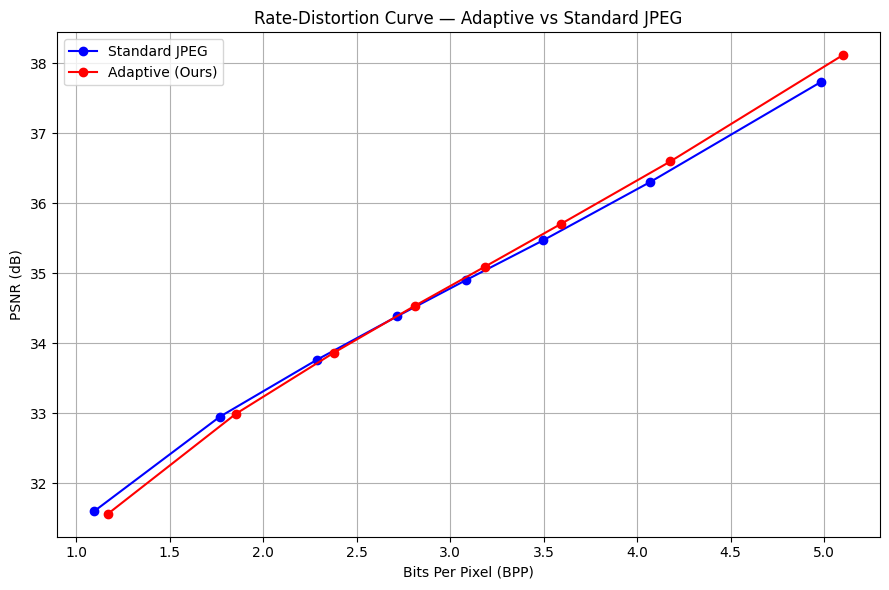

Adaptive SSIM: 0.9172
Standard SSIM: 0.9172
SSIM Gain: -0.0000


In [62]:
qualities = [10, 20, 30, 40, 50, 60, 70, 80]

# use subset for faster evaluation
eval_hr = hr_images[:100]
eval_lr = lr_images[:100]

# -------- precompute importance maps --------
print("Precomputing importance maps...")
importance_maps = []

model.eval()
with torch.no_grad():
    for hr, lr in zip(eval_hr, eval_lr):
        img = np.concatenate([hr / 255.0, lr / 255.0], axis=2)
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float().to(device)

        imp = model(img_tensor)
        imp = normalize_importance(imp)
        imp = imp.squeeze().cpu().numpy()

        importance_maps.append(imp)

print(f"Done. {len(importance_maps)} maps ready.")

adaptive_points = []
standard_points = []

ssim_list = []
std_ssim_list = []

for q in qualities:
    rmse_list, bpp_list = [], []
    std_rmse_list, std_bpp_list = [], []

    for hr, imp in zip(eval_hr, importance_maps):

        # -------- adaptive compression --------
        compressed, bits = cu.process_image_bitrate_neutral(hr, q, imp, alpha=1.0)

        rmse = cu.calculate_rmse(hr, compressed)
        bpp = bits / (hr.shape[0] * hr.shape[1])
        ssim_val = calculate_ssim(hr, compressed)

        rmse_list.append(rmse)
        bpp_list.append(bpp)
        ssim_list.append(ssim_val)

        # -------- standard compression --------
        std_img, std_bits = cu.process_image_standard(hr, q)

        std_rmse = cu.calculate_rmse(hr, std_img)
        std_bpp = std_bits / (hr.shape[0] * hr.shape[1])
        std_ssim_val = calculate_ssim(hr, std_img)

        std_rmse_list.append(std_rmse)
        std_bpp_list.append(std_bpp)
        std_ssim_list.append(std_ssim_val)

    # compute averages
    avg_psnr = 20 * np.log10(255.0 / np.mean(rmse_list))
    avg_bpp = np.mean(bpp_list)

    std_psnr = 20 * np.log10(255.0 / np.mean(std_rmse_list))
    std_bpp_val = np.mean(std_bpp_list)

    adaptive_points.append((avg_bpp, avg_psnr))
    standard_points.append((std_bpp_val, std_psnr))

    print(f"Q={q:3d} | Adaptive {avg_bpp:.3f} BPP {avg_psnr:.2f} dB | Standard {std_bpp_val:.3f} BPP {std_psnr:.2f} dB")

# -------- RD curve plot --------
plt.figure(figsize=(9, 6))
plt.plot([p[0] for p in standard_points], [p[1] for p in standard_points], 'b-o', label='Standard JPEG')
plt.plot([p[0] for p in adaptive_points], [p[1] for p in adaptive_points], 'r-o', label='Adaptive (Ours)')

plt.xlabel('Bits Per Pixel (BPP)')
plt.ylabel('PSNR (dB)')
plt.title('Rate-Distortion Curve — Adaptive vs Standard JPEG')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('rd_curve_final.png', dpi=150)
plt.show()

# -------- SSIM summary --------
avg_ssim = np.mean(ssim_list)
std_ssim = np.mean(std_ssim_list)

print(f"Adaptive SSIM: {avg_ssim:.4f}")
print(f"Standard SSIM: {std_ssim:.4f}")
print(f"SSIM Gain: {avg_ssim - std_ssim:+.4f}")

# Per-Image Comparison

Displays per-image metrics for adaptive and standard compression at a fixed quality level, highlighting variations in performance across different inputs.


In [63]:
# -------- per-image comparison (Q=40) --------
print(f"\nPer-image results at Q=40:")
print(f"{'Image':>6} | {'Adap BPP':>8} | {'Std BPP':>7} | {'Adap PSNR':>9} | {'Std PSNR':>8} | {'SSIM Gain':>9}")

for i, (r, b, sr, sb, ss, sss) in enumerate(
    zip(rmse_list, bpp_list, std_rmse_list, std_bpp_list, ssim_list, std_ssim_list)
):
    # compute PSNR for adaptive and standard
    ap = 20 * np.log10(255.0 / r)
    sp = 20 * np.log10(255.0 / sr)

    print(f"{i+1:>6} | {b:>8.3f} | {sb:>7.3f} | {ap:>9.2f} | {sp:>8.2f} | {ss-sss:>+9.4f}")


Per-image results at Q=40:
 Image | Adap BPP | Std BPP | Adap PSNR | Std PSNR | SSIM Gain
     1 |    6.702 |   6.623 |     34.94 |    34.72 |   +0.0022
     2 |    5.551 |   5.466 |     38.17 |    37.85 |   -0.0017
     3 |    3.612 |   3.436 |     40.23 |    39.71 |   +0.0086
     4 |    5.467 |   5.369 |     37.31 |    37.00 |   +0.0002
     5 |    5.411 |   5.389 |     38.68 |    38.43 |   -0.0052
     6 |    7.128 |   7.150 |     35.44 |    35.36 |   -0.0038
     7 |    6.158 |   6.072 |     37.08 |    36.79 |   +0.0007
     8 |    4.936 |   4.866 |     39.09 |    38.78 |   -0.0014
     9 |    5.553 |   5.475 |     38.49 |    38.03 |   -0.0038
    10 |    5.863 |   5.754 |     37.26 |    36.92 |   +0.0013
    11 |    4.797 |   4.667 |     38.19 |    37.78 |   -0.0026
    12 |    5.096 |   4.859 |     38.35 |    37.64 |   +0.0036
    13 |    3.651 |   3.409 |     39.79 |    39.23 |   +0.0068
    14 |    6.325 |   6.284 |     36.86 |    36.61 |   -0.0046
    15 |    5.544 |   5.409

# Importance Map Visualization

Visualizes the predicted importance map alongside the original image, highlighting regions prioritized by the model. An enhanced view is also shown to better reveal subtle variations in importance values.


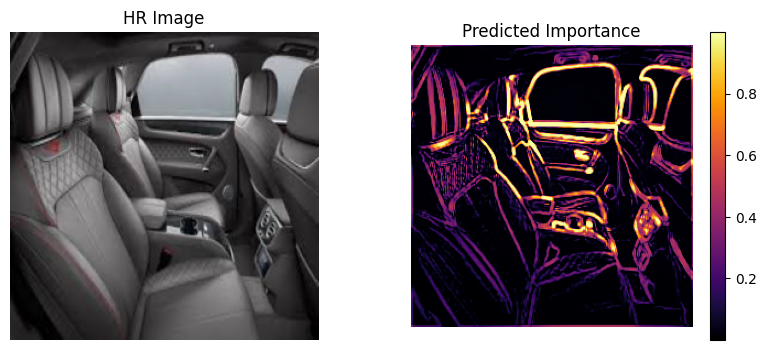

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

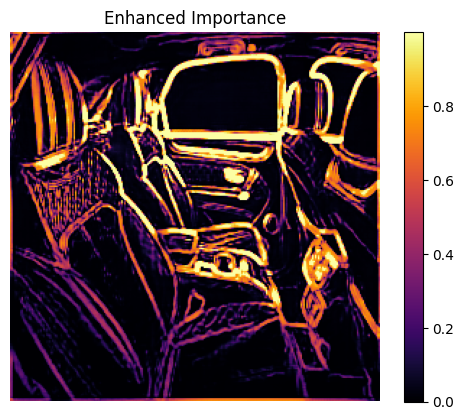

In [64]:
import matplotlib.pyplot as plt

model.eval()

# select a random sample
idx = random.randint(0, len(hr_images) - 1)
test_hr = hr_images[idx]
test_lr = lr_images[idx]

with torch.no_grad():
    # prepare 6-channel input
    img = np.concatenate([test_hr / 255.0, test_lr / 255.0], axis=2)
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float().to(device)

    # predict importance map
    pred_map = model(img_tensor).cpu().squeeze().numpy()

# normalize for visualization
pred_map = pred_map / (pred_map.max() + 1e-6)

# -------- basic visualization --------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(test_hr)
plt.title("HR Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_map, cmap='inferno')
plt.colorbar()
plt.title("Predicted Importance")
plt.axis("off")

plt.show()

# -------- enhanced visualization --------
pred_vis = np.log1p(pred_map)  # enhance contrast in low values

low, high = np.percentile(pred_vis, 5), np.percentile(pred_vis, 95)
pred_vis = np.clip(pred_vis, low, high)

# normalize for display
pred_vis = (pred_vis - low) / (high - low + 1e-6)

plt.imshow(pred_vis, cmap='inferno')
plt.colorbar()
plt.title("Enhanced Importance")
plt.axis("off")

# Importance vs Compression Error

Compares the learned importance map with the actual error produced by standard JPEG compression. A higher correlation indicates that the model is correctly identifying regions that are harder to compress.


In [65]:
def compression_error_map(original, compressed):
    # compute per-pixel absolute error (averaged across channels)
    err = np.abs(original.astype(float) - compressed.astype(float)).mean(axis=2)

    # normalize for visualization and comparison
    return err / (err.max() + 1e-6)


# generate baseline compression
std_compressed, _ = cu.process_image_standard(hr, 40)

# regions where standard compression performs poorly
error_map = compression_error_map(hr, std_compressed)

# correlate learned importance with compression error
corr = np.corrcoef(importance.flatten(), error_map.flatten())[0, 1]

print(f"Importance-Error correlation: {corr:.4f}")

Importance-Error correlation: 0.0466


# Visual Comparison

Compares standard JPEG and importance-guided compression against the original image, alongside the predicted importance map. This highlights how the model allocates higher quality to visually significant regions.


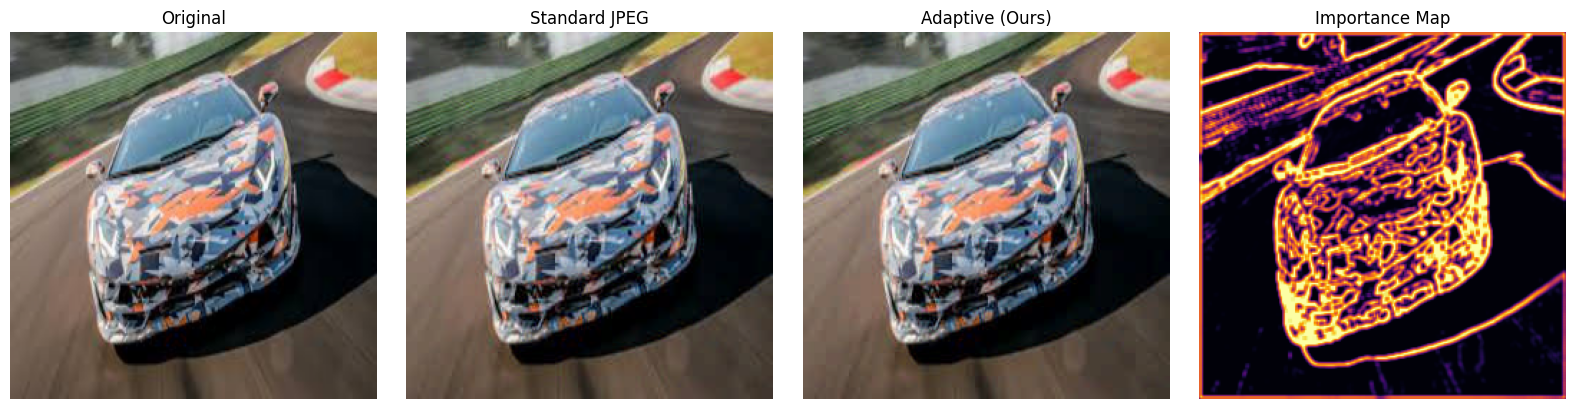

In [66]:
import matplotlib.pyplot as plt

model.eval()

# pick a random example
idx = random.randint(0, len(hr_images) - 1)
test_hr = hr_images[idx]
test_lr = lr_images[idx]

# -------- importance map --------
with torch.no_grad():
    img = np.concatenate([test_hr / 255.0, test_lr / 255.0], axis=2)
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float().to(device)

    importance = model(img_tensor)
    importance = normalize_importance(importance)
    importance = importance.squeeze().cpu().numpy()

# normalize for display
importance_vis = importance / (importance.max() + 1e-6)

# -------- compressions --------
# standard JPEG
std_img, _ = cu.process_image_standard(test_hr, 40)

# adaptive (your method)
adaptive_img, _ = cu.process_image_bitrate_neutral(test_hr, 40, importance, alpha=1.0)

# -------- plot --------
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(test_hr)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(std_img)
plt.title("Standard JPEG")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(adaptive_img)
plt.title("Adaptive (Ours)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(importance_vis, cmap='inferno')
plt.title("Importance Map")
plt.axis("off")

plt.tight_layout()
plt.show()

# Save Results

Saves the trained model, rate–distortion data, and generated plots for later use and reproducibility.


In [68]:
# -------- save model and results --------

# save trained model
torch.save(model.state_dict(), "/content/drive/MyDrive/imagecompression/final_model.pth")

# save RD curve data
np.save("adaptive_points.npy", adaptive_points)
np.save("standard_points.npy", standard_points)

# save RD curve plot
plt.savefig("/content/drive/MyDrive/imagecompression/rd_curve_final.png", dpi=150)

print("Saved model, RD data, and plots.")

Saved model, RD data, and plots.


<Figure size 640x480 with 0 Axes>